In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
import sys

In [3]:
df = pd.read_excel('Telco_customer_churn_cleaned.xlsx')
print(df.head())

   customerid  count        country       state         city  zip_code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 lat_long   latitude   longitude  gender  ...  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...   

              payment_method monthly_charges total_charges  churn_label  \
0               Mailed check           53.85        108.15          Yes   
1           El

In [4]:
df.shape

(7043, 35)

In [5]:
df.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason', 'tenure_group',
       'monthly_charges_segment'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               7043 non-null   str    
 1   count                    7043 non-null   int64  
 2   country                  7043 non-null   str    
 3   state                    7043 non-null   str    
 4   city                     7043 non-null   str    
 5   zip_code                 7043 non-null   int64  
 6   lat_long                 7043 non-null   str    
 7   latitude                 7043 non-null   float64
 8   longitude                7043 non-null   float64
 9   gender                   7043 non-null   str    
 10  senior_citizen           7043 non-null   str    
 11  partner                  7043 non-null   str    
 12  dependents               7043 non-null   str    
 13  tenure_months            7043 non-null   int64  
 14  phone_service            7043 non-n

In [7]:
df.isnull().sum()

customerid                    0
count                         0
country                       0
state                         0
city                          0
zip_code                      0
lat_long                      0
latitude                      0
longitude                     0
gender                        0
senior_citizen                0
partner                       0
dependents                    0
tenure_months                 0
phone_service                 0
multiple_lines                0
internet_service              0
online_security               0
online_backup                 0
device_protection             0
tech_support                  0
streaming_tv                  0
streaming_movies              0
contract                      0
paperless_billing             0
payment_method                0
monthly_charges               0
total_charges                11
churn_label                   0
churn_value                   0
churn_score                   0
cltv    

In [8]:
(df.isnull().sum()/len(df))*100

customerid                  0.000000
count                       0.000000
country                     0.000000
state                       0.000000
city                        0.000000
zip_code                    0.000000
lat_long                    0.000000
latitude                    0.000000
longitude                   0.000000
gender                      0.000000
senior_citizen              0.000000
partner                     0.000000
dependents                  0.000000
tenure_months               0.000000
phone_service               0.000000
multiple_lines              0.000000
internet_service            0.000000
online_security             0.000000
online_backup               0.000000
device_protection           0.000000
tech_support                0.000000
streaming_tv                0.000000
streaming_movies            0.000000
contract                    0.000000
paperless_billing           0.000000
payment_method              0.000000
monthly_charges             0.000000
t

In [10]:
#find duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
#target variable analysis

In [15]:
#churn distribution
df['churn_label'].value_counts()


churn_label
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
# percentage distribution of churn
df['churn_label'].value_counts(normalize=True)*100

churn_label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [17]:
# numerical features analysis


# tenure_months
# monthly_charges
# total_charges
# churn_score

In [18]:
#descriptive analysis
df.describe()

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,total_charges,churn_value,churn_score,cltv
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


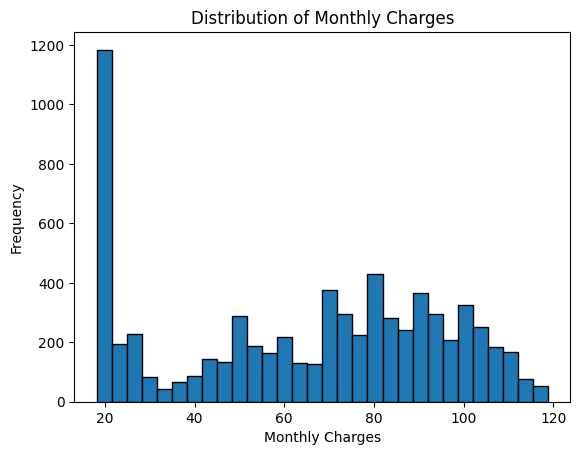

In [19]:
#plot histogram for monthly_charges
plt.hist(df['monthly_charges'], bins=30, edgecolor='k') 
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')  
plt.ylabel('Frequency')
plt.show()

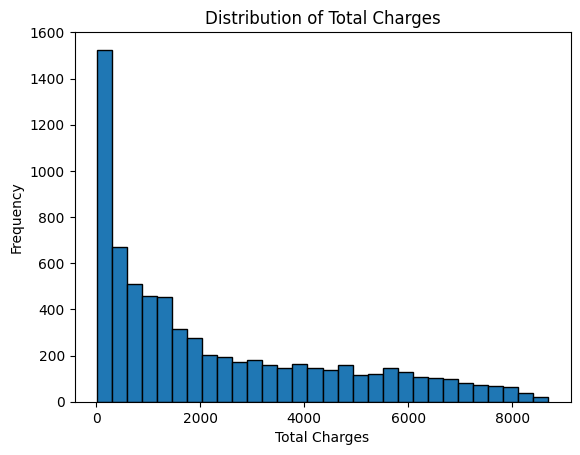

In [21]:
# histogram for total_charges
plt.hist(df['total_charges'], bins=30, edgecolor='k')   
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()


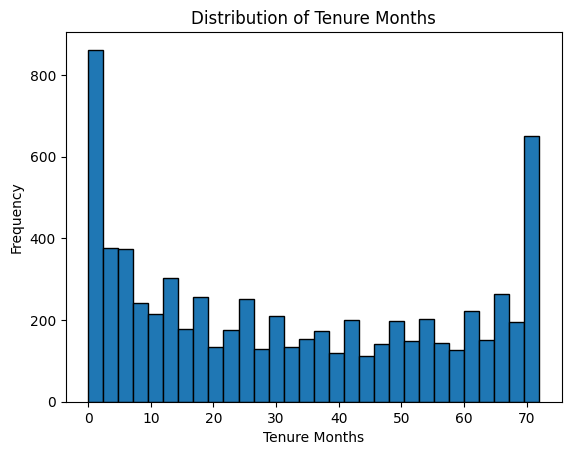

In [22]:
#histogram for tenure_months
plt.hist(df['tenure_months'], bins=30, edgecolor='k')   
plt.title('Distribution of Tenure Months')
plt.xlabel('Tenure Months')
plt.ylabel('Frequency')
plt.show()

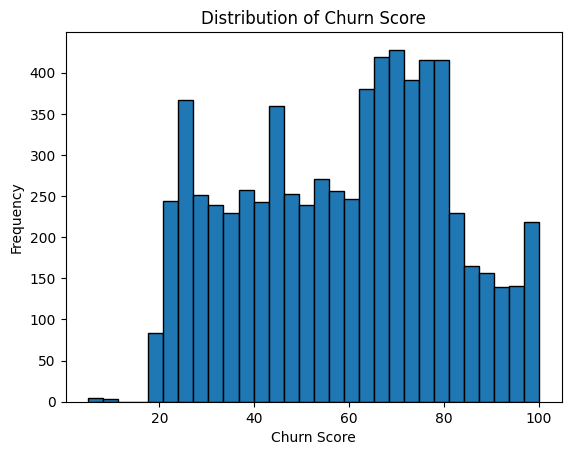

In [23]:
# histogram for churn_score
plt.hist(df['churn_score'], bins=30, edgecolor='k')
plt.title('Distribution of Churn Score')
plt.xlabel('Churn Score')   
plt.ylabel('Frequency')
plt.show()

#  Outlier Analysis

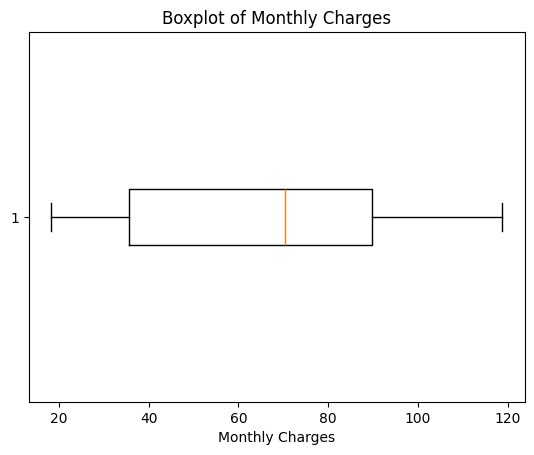

In [24]:
#boxplot for monthly_charges
plt.boxplot(df['monthly_charges'], vert=False)  
plt.title('Boxplot of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.show()

# define extreme values in words as comments
 extreme values for monthly_charges are those greater than $100, which may indicate high spending customers or potential outliers.
 
 extreme values for total_charges are those greater than $5000, which may indicate long-term customers with high cumulative charges or potential outliers.

In [59]:
# print extreme values for monthly_charges
print("Extreme values for Monthly Charges:")
print(df[df['monthly_charges'] > 100]['monthly_charges'])

Extreme values for Monthly Charges:
3       104.80
4       103.70
12      106.35
24      110.00
27      100.25
         ...  
7013    105.40
7026    104.95
7027    103.50
7040    103.20
7042    105.65
Name: monthly_charges, Length: 902, dtype: float64


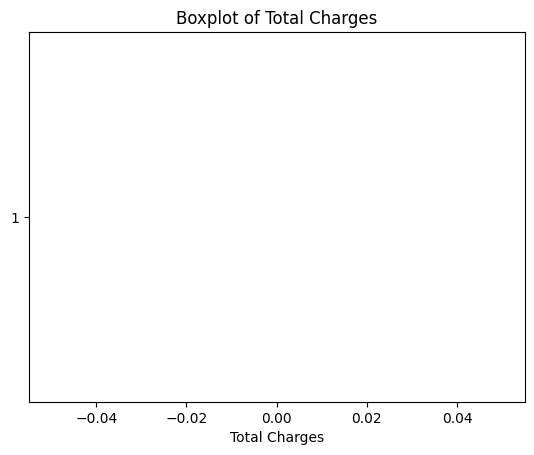

Extreme values for Total Charges:
4       5036.30
24      7611.85
25      5238.90
41      5000.20
70      5624.85
         ...   
7018    5150.55
7026    7544.30
7027    6479.40
7040    7362.90
7042    6844.50
Name: total_charges, Length: 1135, dtype: float64


In [60]:
# boxplot for total_charges and print extreme values
plt.boxplot(df['total_charges'], vert=False)
plt.title('Boxplot of Total Charges')
plt.xlabel('Total Charges')
plt.show()
print("Extreme values for Total Charges:")
print(df[df['total_charges'] > 5000]['total_charges'])


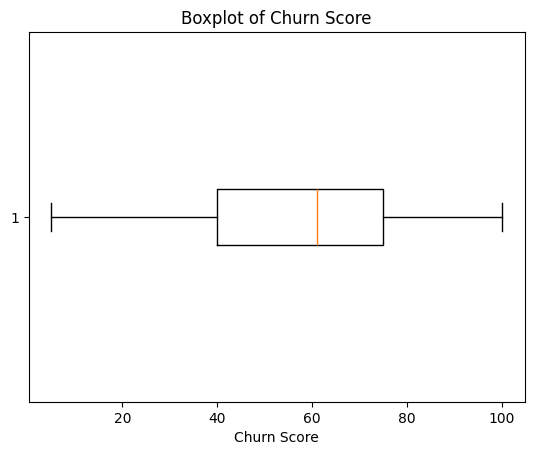

Extreme values for Churn Score:
0       86
1       67
2       86
3       84
4       89
        ..
7038    45
7039    59
7040    71
7041    59
7042    38
Name: churn_score, Length: 7043, dtype: int64


In [61]:
# boxplot for churn_score and print extreme values
plt.boxplot(df['churn_score'], vert=False)
plt.title('Boxplot of Churn Score')
plt.xlabel('Churn Score')
plt.show()
print("Extreme values for Churn Score:")
print(df[df['churn_score'] > 0.8]['churn_score'])
# extreme values for churn_score are those greater than 0.8, which may indicate customers with a high likelihood of churning.

Categorical Analysis

Important columns:

gender

contract

internet_service

payment_method

tech_support

online_security

paperless_billing

In [62]:
#frequency table 
     
df['contract'].value_counts()


contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [63]:
#percentage distribution of contract types
df['contract'].value_counts(normalize=True)*100

contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

In [64]:
# contract vs churn_label
pd.crosstab(df['contract'], df['churn_label'])



churn_label,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [65]:
#internet_service vs churn_label
pd.crosstab(df['internet_service'], df['churn_label'])

churn_label,No,Yes
internet_service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [66]:
#payment_method vs churn_label
pd.crosstab(df['payment_method'], df['churn_label'])

churn_label,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [67]:
#senior_citizen vs churn_label  
pd.crosstab(df['senior_citizen'], df['churn_label'])

churn_label,No,Yes
senior_citizen,,
No,4508,1393
Yes,666,476


In [68]:
#tech_support vs churn_label
pd.crosstab(df['tech_support'], df['churn_label'])

churn_label,No,Yes
tech_support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


numerical columns vs churn


In [69]:
#monthly_charges vs churn_label
df.groupby('churn_label')['monthly_charges'].mean()


churn_label
No     61.265124
Yes    74.441332
Name: monthly_charges, dtype: float64

In [70]:
#tenure vs churn_label
df.groupby('churn_label')['tenure_months'].mean()

churn_label
No     37.569965
Yes    17.979133
Name: tenure_months, dtype: float64

In [71]:
#total_charges vs churn_label
df.groupby('churn_label')['total_charges'].mean()

churn_label
No     2555.344141
Yes    1531.796094
Name: total_charges, dtype: float64

correlation analysis


In [72]:
#Numeric columns select:

numeric_df = df.select_dtypes(include='number')

In [73]:
numeric_df.corr()

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,total_charges,churn_value,churn_score,cltv
count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.001462,0.003346,-0.002769,-0.003562
latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.010313,-0.003384,-0.007684,0.000886
longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.009047,0.004594,0.004260,0.000485
tenure_months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.825880,-0.352229,-0.224987,0.396406
monthly_charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651065,0.193356,0.133754,0.098693
total_charges,NaN,-0.001462,-0.010313,0.009047,0.825880,0.651065,1.000000,-0.199484,-0.124312,0.341837
churn_value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.199484,1.000000,0.664897,-0.127463
churn_score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.124312,0.664897,1.000000,-0.079782
cltv,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,0.341837,-0.127463,-0.079782,1.000000


<Axes: >

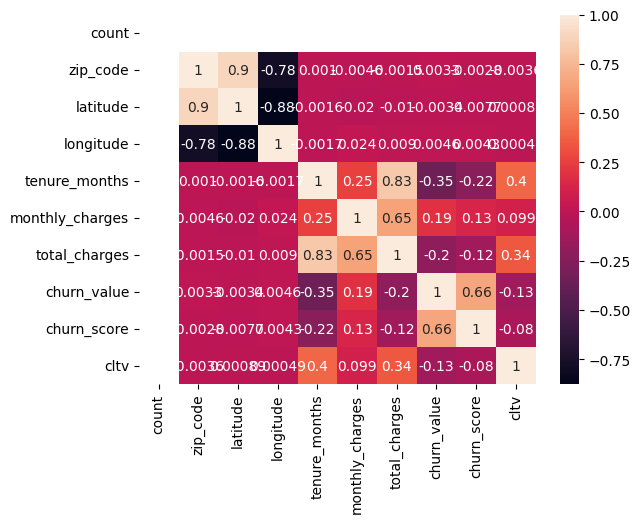

In [74]:
import seaborn as sns

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

geographic analysis

In [75]:
# top 10 cities with highest churn
df[df['churn_label']=='Yes']['city'].value_counts().head(10)

city
Los Angeles      90
San Diego        50
San Francisco    31
San Jose         29
Sacramento       26
Fresno           16
Long Beach       15
Glendale         13
Oakland          13
Stockton         12
Name: count, dtype: int64

In [76]:
#top 10 states with highest churn
df[df['churn_label']=='Yes']['state'].value_counts().head(10)

state
California    1869
Name: count, dtype: int64

* Business Insights


Insight 1

Month-to-month contract customers show highest churn.

Insight 2

Customers without tech support churn more.

Insight 3

Higher monthly charges correlate with higher churn.

Insight 4

New customers (low tenure) are more likely to churn.

Insight 5

Electronic check/payment method customers have higher churn.


- Final Deliverable

1. Dataset Overview
2. Missing Values
3. Duplicates
4. Target Analysis
5. Numerical Analysis
6. Outlier Detection
7. Categorical Analysis
8. Churn vs Features
9. Correlation Analysis
10. Geographic Analysis
11. Key Business Insights
